# **DPW7 - alpha sweep with different turbulence models and UDD example**

This notebook shows how to set up the simulations based on meshes provided during the [VII Drag prediction workshop](https://aiaa-dpw.larc.nasa.gov/Workshop7/workshop7.html). The meshes downloaded will correspond to the given angles of attack. Every AoA will be simulated using the Spallart-Allmaras and k-Omega SST turbulence models. Using the grid for AoA=2.5 degrees there will be an AoA-controlling user defined dynamic implemented that will "search" for an AoA corresponding to the coefficient of lift of 0.5.

The tutorial will walk through all of the important steps of setting up CFD runs as well as through some post-processing steps including generating images using provided TecPlot macros and plotting different characteristics.

Firstly we will import all of the neessary libraries.

In [1]:
import flow360 as fl
import os
import pandas as pd
import numpy as np
from urllib.request import urlretrieve
import tarfile
import vtk
import matplotlib.pyplot as plt
from vtkmodules.util import numpy_support

import tecplot as tp
from tecplot.exception import *
from tecplot.constant import *

Turn off logging for clear cell outputs.

In [2]:
from flow360.log import log
from flow360.log import log, set_logging_level

log.log_to_file = False
set_logging_level("INFO")

Then we will define some important variables that wll be useful later on.

In [3]:
# Reynolds number provided by Workshop
REYNOLDS = 20e06

# MAC
CHORD = 1.0 * fl.u.m

# Scale of the model 
scale = 1 / 7.447

# list of slices at which outputs will be defined, scaled to SI
Y_SLICES = np.array([121.459, 133.026, 144.594, 151.074, 232.444, 
            327.074, 396.765, 427.998, 459.37,581.148, 697.333,
            840.704,978.148,1098.926,1122.048,1145.183]) * 0.0254 * scale

# AoA angles in the sweep
alphas = [2.50,2.75,3.00,3.25,3.50,3.75,4.00,4.25]

# studied turbulence models
tb_models = ["SA", "SST"]

## Solution configuration

The function defined below is used to generate SimulationParams objects used to run each case depending on the AoA of each case and the turbulence model. User defined dynamics is defined only for the case with AoA of 2.5 degrees. The UDD implements a simple PI controller that changes alpha a sthe controlled variable to obtained a given Cl as an output variable.

In [4]:
# Based on JAXA grids.
# Baseline DPW7 solver configuration

def generate_params(volume_mesh: fl.VolumeMesh, alpha, turbulence_model:str):

    if turbulence_model not in ["SA", "SST"]:
        raise ValueError("Choose correct turbulence model: 'SA' - SpalartAllmaras, 'SST' - kOmegaSST.")
    
    vm = volume_mesh
    slip_walls = ["20", "22"]
    freestream = ["21"]
    walls = list(set(volume_mesh.boundary_names) - set(slip_walls) - set(freestream))
    walls = [vm[i] for i in walls]

    with fl.SI_unit_system:
        params = fl.SimulationParams(
            reference_geometry=fl.ReferenceGeometry(
                area=3.90925521694,
                moment_center=(4.80746918057, 0.0, 0.64521392313),
                moment_length=1.0,
            ),
            operating_condition=fl.operating_condition_from_mach_reynolds(
                mach=0.85,
                reynolds=REYNOLDS,
                alpha=alpha * fl.u.deg,
                temperature=116.483 * fl.u.K,
                project_length_unit=1 * fl.u.m
            ),
            time_stepping=fl.Steady(
                max_steps=4000, CFL=fl.RampCFL(initial=1, final=200, ramp_steps=2000)
            ),
            models=[
                fl.Wall(surfaces=walls, name="Wall"),
                fl.Freestream(surfaces=[vm[i] for i in freestream], name="Freestream"),
                fl.SlipWall(surfaces=[vm[i] for i in slip_walls], name="SlipWall"),
                fl.Fluid(
                    navier_stokes_solver=fl.NavierStokesSolver(
                        absolute_tolerance=1e-10,
                        linear_solver=fl.LinearSolver(max_iterations=35),
                        update_jacobian_frequency=4,
                    ),
                    turbulence_model_solver=fl.SpalartAllmaras(
                        absolute_tolerance=1e-8,
                        linear_solver=fl.LinearSolver(max_iterations=25),
                        update_jacobian_frequency=4,
                        equation_evaluation_frequency=1,
                        rotation_correction="true",
                        quadratic_constitutive_relation="true",
                    ) if turbulence_model=="SA" else fl.KOmegaSST(
                        absolute_tolerance=1e-8,
                        linear_solver=fl.LinearSolver(max_iterations=25),
                        update_jacobian_frequency=4,
                        equation_evaluation_frequency=1,
                        rotation_correction="true",
                        quadratic_constitutive_relation="true",
                    ),
                ),
            ],
            outputs=[
                fl.VolumeOutput(
                    output_format="tecplot",
                    output_fields=["primitiveVars", "qcriterion", "Mach", "mutRatio"],
                ),
                fl.SurfaceOutput(
                    output_format="tecplot",
                    output_fields=[
                        "primitiveVars",
                        "Cp",
                        "Cf",
                        "CfVec",
                        "yPlus",
                        "nodeForcesPerUnitArea",
                    ],
                    surfaces=walls,
                ),
                fl.SurfaceSliceOutput(
                    name="wing_sections",
                    entities=[fl.Slice(name=f"slice y={y:.2f}", origin=(0, y, 0), normal=(0, 1, 0)) for y in Y_SLICES],
                    target_surfaces=walls,
                    output_fields=[
                        "Cp",
                        "Cf",
                        "CfVec",
                        "yPlus",
                    ],
                ),
            ],
            user_defined_dynamics=[
                fl.UserDefinedDynamic(
                    name="alphaController",
                    input_vars=["CL"],
                    constants={"CLTarget": 0.5, "Kp": 0.1, "Ki": 0.001},
                    output_vars={
                        "alphaAngle": "if (pseudoStep > 1500) state[0]; else alphaAngle;"
                    },
                    state_vars_initial_value=["alphaAngle", "2.5"],
                    update_law=[
                        "if (pseudoStep > 1500) state[0] + Kp * (CLTarget - CL) + Ki * state[1]; else state[0];",
                        "if (pseudoStep > 1500) state[1] + (CLTarget - CL); else state[1];",
                    ],
                    input_boundary_patches=walls,
                )
            ] if alpha == 2.5 else None,
        )

    return params

## Uploading the meshes and running the cases

For each mesh a different project will be created. The dataframe created below will store the information about the projects to then easily access them in the cloud by their id.

In [ ]:
# Creating a directory for the downloaded meshes 
meshes_path = os.path.join(os.getcwd(), "Meshes")
os.makedirs(meshes_path, exist_ok=True)
print(f"Meshes will be saved to: {meshes_path}")

# Creating a dataframe for the project info (or reading if is already existent)
project_file = "project_list.csv"
if os.path.exists(project_file):
    projects = pd.read_csv(project_file)
else:
    projects = pd.DataFrame(columns=["alpha", "project_name", "project_id", "volume_mesh_id"])

print("Project info:")
projects

### Function for retreiving project IDs for certain alpha angles

Two helper functions are then defined: to extract project with a given alpha angle and to extract a turbulence model from a ran case.

In [6]:
def get_project_id_for_alpha(alpha, projects):
    '''Returns project ID and the position in the dataframe'''
    matching_rows = projects[projects['alpha'] == alpha]
    if not matching_rows.empty:
        return matching_rows['project_id'].iloc[0], matching_rows.index[0]
    else:
        return None, len(projects.index)
    
def extract_turbulence_model_solver(case: fl.Case):
    models = case.params.models
    for model in models:
        if isinstance(model, fl.Fluid):
            return model.turbulence_model_solver
    return None

## Submitting and running the case for AoA = 2.5, SA model

The cells below provide a step by step instructions on how to submit a single case to cloud for solution.

#### Downloading the mesh

In [7]:
alpha = 2.5
tb_model = "SA"

download_mesh_name = f"CRM_wb_ih+0_UnstrMixed_JAXA_mediumRev00_LoQ{alpha:.2f}.b8.ugrid.gz"
local_mesh_name = os.path.join(meshes_path, download_mesh_name)

# if meshes not present in Meshes directory, try downloading them from DPW7 website
if not os.path.isfile(local_mesh_name):
    print(f"DOWNLOADING MESH, {alpha=:.2f}")
    url = f"https://dpw.larc.nasa.gov/DPW7/JAXA_Grids.REV00/{download_mesh_name}"
    urlretrieve(url, local_mesh_name)

#### Creating a project for the volume mesh

In [8]:
project_id, row_index = get_project_id_for_alpha(alpha, projects)
if project_id == None:
    # create project and upload volume mesh
    project = fl.Project.from_volume_mesh(local_mesh_name, name=f"DPW7_JAXA_medium_LoQ_AoA{alpha:.2f}")
    projects.loc[row_index] = [alpha, project.metadata.name, project.id, project.volume_mesh.id]
    projects.to_csv(project_file, index=False)
else:
    project = fl.Project.from_cloud(project_id=project_id)


#### Running the case

In [ ]:
cases = project.get_case_ids()

tb_models_calculated = [("SA" if isinstance(extract_turbulence_model_solver(fl.Case(case_id)), fl.SpalartAllmaras) 
                        else ("SST" if isinstance(extract_turbulence_model_solver(fl.Case(case_id)), fl.KOmegaSST) else None)) 
                        for case_id in cases]

# run the case if it has not been ran previously
if tb_model not in tb_models_calculated:
    params = generate_params(project.volume_mesh, alpha, tb_model)
    project.run_case(params=params, name=f"{project.metadata.name}_{tb_model}")

### Loop for all of the angles

Finally the process is concentrated in a single block that loops through all AoA - turbulence model combinations and submits appropriate cases for solution.

In [10]:
for alpha in alphas:
    for tb_model in tb_models:
        download_mesh_name = f"CRM_wb_ih+0_UnstrMixed_JAXA_mediumRev00_LoQ{alpha:.2f}.b8.ugrid.gz"
        local_mesh_name = os.path.join(meshes_path, download_mesh_name)

        # if meshes not present in Meshes directory, try downloading them from DPW7 website
        if not os.path.isfile(local_mesh_name):
            print(f"DOWNLOADING MESH, {alpha=:.2f}")
            url = f"https://dpw.larc.nasa.gov/DPW7/JAXA_Grids.REV00/{download_mesh_name}"
            urlretrieve(url, local_mesh_name)

        project_id, row_index = get_project_id_for_alpha(alpha, projects)
        if project_id == None:
            # create project and upload volume mesh
            project = fl.Project.from_volume_mesh(local_mesh_name, name=f"DPW7_JAXA_medium_LoQ_AoA{alpha:.2f}")
            projects.loc[row_index] = [alpha, project.metadata.name, project.id, project.volume_mesh.id, None]
            projects.to_csv(project_file, index=False)
        else:
            project = fl.Project.from_cloud(project_id=project_id)

        cases = project.get_case_ids()

        tb_models_calculated = [("SA" if isinstance(extract_turbulence_model_solver(fl.Case(case_id)), fl.SpalartAllmaras) 
                                else ("SST" if isinstance(extract_turbulence_model_solver(fl.Case(case_id)), fl.KOmegaSST) else None)) 
                                for case_id in cases]

        # run the case if it has not been ran previously
        if tb_model not in tb_models_calculated:
            params = generate_params(project.volume_mesh, alpha, tb_model)
            project.run_case(params=params, name=f"{project.metadata.name}_{tb_model}")

Output()

[11:37:04] INFO: using: SI unit system for unit inference.

Output()

[11:37:05] INFO: using: SI unit system for unit inference.

Output()

...

[11:38:37] INFO: using: SI unit system for unit inference.

Output()

[11:38:39] INFO: using: SI unit system for unit inference.

Output()

[11:38:40] INFO: using: SI unit system for unit inference.

## Downloading and postprocessing the results

After the cases finished running (which can be checked in WebUI) we begin post-processing the results. This notebook shows a manual approach to working with the output data which consists of downloading the raw results and processing them inside the script. More automatic approaches are also available: different results objects have methods that make processing easier and the report plugin can help automate generating reports documenting the analyses. 

Firstly the project list is read into the projects variable and a folder for results files is created.

In [ ]:
# run if kernel was restarted
projects = pd.read_csv("project_list.csv")

results_path = os.path.join(os.getcwd(), "Results")
os.makedirs(results_path, exist_ok=True)
print(f"Results will be saved to: {results_path}")

### Downloading

Then we loop through all of the created projects and through cases ran inside them and download the numeric results files.

In [ ]:
for i, row in projects.iterrows():
    for case_id in fl.Project.from_cloud(project_id=row["project_id"]).get_case_ids():
        results = fl.Case(id=case_id).results

        case_path = os.path.join(results_path, fl.Case(id=case_id).name)
        results.set_destination(folder_name=case_path)
        results.download(
            nonlinear_residuals=True,
            surface_forces=True,
            total_forces=True,
            user_defined_dynamics=True,
            overwrite=True
        )

### Extracting the loads

Then a dataframe is prepared to store the processed quantities. The loads are averaged over the last 100 pseudo steps. The data is saved every 10 pseudo steps, this is why the result is the average of the last 10 datapoints. 

In [13]:
data_dumping_rate = 10
n_steps_to_avg = 100

entries_to_avg = n_steps_to_avg // data_dumping_rate

aspect_ratio = 9.0

results_path = os.path.join(os.getcwd(), "Results")
os.makedirs(results_path, exist_ok=True)

alphas = [2.50,2.75,3.00,3.25,3.50,3.75,4.00,4.25]
tb_models = ["SA", "SST"]

wing_zone_ids = list(range(8,20))
fuselage_zone_ids = list(range(1,8))

# preparing the data structure
loads = ['CL', 'CD', 'CDPressure', 'CDSkinFriction', 'CL2PA','CMy']
zones = ['total', 'wing', 'fus']

columns = ["case_name", "alpha", "turbulence_model"]

for zone in zones:
    for load in loads:
        if not (load == 'CL2PA' and zone != 'total'):
            columns.append(f"{load}_{zone}")

loads_df = pd.DataFrame(columns=columns)
loads_df

,case_name,alpha,turbulence_model,CL_total,CD_total,CDPressure_total,CDSkinFriction_total,CL2PA_total,CMy_total,CL_wing,CD_wing,CDPressure_wing,CDSkinFriction_wing,CMy_wing,CL_fus,CD_fus,CDPressure_fus,CDSkinFriction_fus,CMy_fus


The functions defined below are designed to compute the averages and create an entry to the loads_df dataframe.

In [14]:
def compute_loads_total(total_forces, loads):
    loads_total = dict()
    for load in loads:
        if load != "CL2PA":
            value = np.average(total_forces[load][-entries_to_avg:-1])
            loads_total[f"{load}_total"] = value
        else:
            # CL2PA corresponds to idealized profile drag
            value = np.average(total_forces['CD'][-entries_to_avg:-1])-pow(np.average(total_forces[f'CL'][-entries_to_avg:-1]),2)/np.pi/aspect_ratio
            loads_total[f"{load}_total"] = value
    return(loads_total)

def compute_loads_partial(surface_forces, wing_zone_ids, fuselage_zone_ids, loads):
    loads_partial = dict()

    for load in loads:
        if load != "CL2PA":
            value = 0
            for i in wing_zone_ids:
                value += np.average(surface_forces[str(i)+"_"+load][-entries_to_avg:-1])
            loads_partial[f"{load}_wing"] = value

    for load in loads:
        if load != "CL2PA":
            value = 0
            for i in fuselage_zone_ids:
                value += np.average(surface_forces[str(i)+"_"+load][-entries_to_avg:-1])
            loads_partial[f"{load}_fus"] = value
        
    return(loads_partial)

The compute_alpha function extracts the effective averaged alpha from the case with the UDD defined.

The get_case_object function is used to get a case object from the case name.

In [15]:
def compute_alpha(udd_data, entries_to_avg):
    return np.average(udd_data['alphaAngle'][-entries_to_avg:-1])

def get_case_object(project, name):
    ids = project.get_case_ids()
    for id in ids:
        if fl.Case(id).name == name:
            return fl.Case(id)

The functions are then used in a loop that extracts the wanted loads from all of the performed simulations and stores the values in the file

In [ ]:
for alpha in alphas:
    project = fl.Project.from_cloud(project_id=get_project_id_for_alpha(alpha, projects)[0])
    for tb_model in tb_models:
            case_name = f"DPW7_JAXA_medium_LoQ_AoA{alpha:.2f}_{tb_model}"
            csv_path_total = os.path.join(results_path, f'{case_name}','total_forces_v2.csv')
            total_forces = pd.read_csv(csv_path_total, skipinitialspace=True)
            csv_path_surface = os.path.join(results_path ,f'{case_name}','surface_forces_v2.csv')
            surface_forces = pd.read_csv(csv_path_surface, skipinitialspace=True)
            loads_total = compute_loads_total(total_forces, loads)
            loads_partial = compute_loads_partial(surface_forces, wing_zone_ids, fuselage_zone_ids, loads)

            if get_case_object(project, case_name).params.user_defined_dynamics== None:
                alpha_true = get_case_object(project, case_name).params.operating_condition.alpha
            else:
                csv_path = os.path.join(results_path, f'{case_name}','udd_alphaController_v2.csv')
                udd_data = pd.read_csv(csv_path, skipinitialspace=True)
                alpha_true = compute_alpha(udd_data, entries_to_avg)

            loads_row = {"case_name": case_name, "alpha": alpha_true, "turbulence_model": tb_model}
            loads_row.update(loads_total)
            loads_row.update(loads_partial)

            new_row = pd.DataFrame(loads_row, index=[0])

            loads_df = pd.concat([loads_df, new_row], ignore_index=True)
            
loads_df.to_csv(os.path.join(results_path, "loads.csv"), index=False)

## Extracting the solution history

Another important part of each simulation is the convergence. The nonlinear residuals can be found in the **nonlinear_residual_v2.csv** file. Another quantity worth monitoring during the solution are the total loads. The code below extracts the from appropriate files and saves each history to the case-specific file.

In [ ]:
loads = ['CL', 'CD', 'CMy']
residuals_sa = ['0_cont', '1_momx', '2_momy', '3_momz', '4_energ', '5_nuHat']
residuals_sst = ['0_cont', '1_momx', '2_momy', '3_momz', '4_energ', '5_k', '6_omega']

for alpha in alphas:
    project = fl.Project.from_cloud(project_id=get_project_id_for_alpha(alpha, projects)[0])
    for tb_model in tb_models:
        case_name = f"DPW7_JAXA_medium_LoQ_AoA{alpha:.2f}_{tb_model}"
        csv_path_total_forces = os.path.join(results_path, f'{case_name}','total_forces_v2.csv')
        total_forces = pd.read_csv(csv_path_total_forces, skipinitialspace=True)
        csv_path_residuals = os.path.join(results_path, f'{case_name}','nonlinear_residual_v2.csv')
        residuals = pd.read_csv(csv_path_residuals, skipinitialspace=True)

        if get_case_object(project, case_name).params.user_defined_dynamics==None:
            alpha_hist = pd.Series([get_case_object(project, case_name).params.operating_condition.alpha] * len(residuals))
        else:
            csv_path = os.path.join(results_path, f'{case_name}','udd_alphaController_v2.csv')
            udd_data = pd.read_csv(csv_path, skipinitialspace=True)
            alpha_hist = udd_data['alphaAngle']

        iterative_history = pd.DataFrame(total_forces['pseudo_step'])

        iterative_history = iterative_history.join([alpha_hist, total_forces[loads], 
                                residuals[residuals_sa] if tb_model=="SA" else (
                                    residuals[residuals_sst] if tb_model=="SST" else None)])
        
        case_path = os.path.join(results_path, case_name)

        iterative_history.to_csv(os.path.join(case_path, "iterative_history.csv"), index=False)

## Generating images

### Download surface results

In [18]:
for i, row in projects.iterrows():
    for case_id in fl.Project.from_cloud(project_id=row["project_id"]).get_case_ids():
        results = fl.Case(id=case_id).results

        case_path = os.path.join(results_path, fl.Case(id=case_id).name)
        results.set_destination(folder_name=case_path)
        results.download(
            surface=True,
            overwrite=True
        )

        with tarfile.open(os.path.join(case_path, "surfaces.tar.gz")) as f:
            f.extractall(os.path.join(case_path, "surfaces"))


Output()

[11:43:15] INFO: Saved to c:\Code\DPW7\Results\DPW7_JAXA_medium_LoQ_AoA2.50_SST\surfaces.tar.gz

Output()

[11:43:29] INFO: Saved to c:\Code\DPW7\Results\DPW7_JAXA_medium_LoQ_AoA2.50_SA\surfaces.tar.gz

Output()

...

[11:46:14] INFO: Saved to c:\Code\DPW7\Results\DPW7_JAXA_medium_LoQ_AoA4.00_SA\surfaces.tar.gz

Output()

[11:46:25] INFO: Saved to c:\Code\DPW7\Results\DPW7_JAXA_medium_LoQ_AoA4.25_SA\surfaces.tar.gz

Output()

[11:46:34] INFO: Saved to c:\Code\DPW7\Results\DPW7_JAXA_medium_LoQ_AoA4.25_SST\surfaces.tar.gz

Using the vtk library we will extract the surface slice data from the .pvtu files and plot them using matplotlib.

#### Plotting a single profile.
First, necessary variables describing the slice and the locations of case output files are defined.

In [19]:
vtu_reader = vtk.vtkXMLPUnstructuredGridReader()
row = projects.iloc[0]
case_id = fl.Project.from_cloud(project_id=row["project_id"]).case.id
slice = Y_SLICES[2]
case_path = os.path.join(results_path, fl.Case(id=case_id).name)
file_location = os.path.join(case_path, "surfaces")
filename = f"surface_slice_slice y={slice:.2f}.pvtu"
base_path = os.getcwd()
os.chdir(file_location)

Next, using the vtu reader, the numeric point data is extracted from the vtu file.

In [20]:
vtu_reader.SetFileName(filename)
vtu_reader.Update()
cps = numpy_support.vtk_to_numpy(vtu_reader.GetOutput().GetPointData().GetArray("Cp"))
coords = numpy_support.vtk_to_numpy(vtu_reader.GetOutput().GetPoints().GetData())
os.chdir(base_path)

Then the plot is created using these points.

C:\Users\Piotr\AppData\Local\Temp\ipykernel_816\2367370763.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


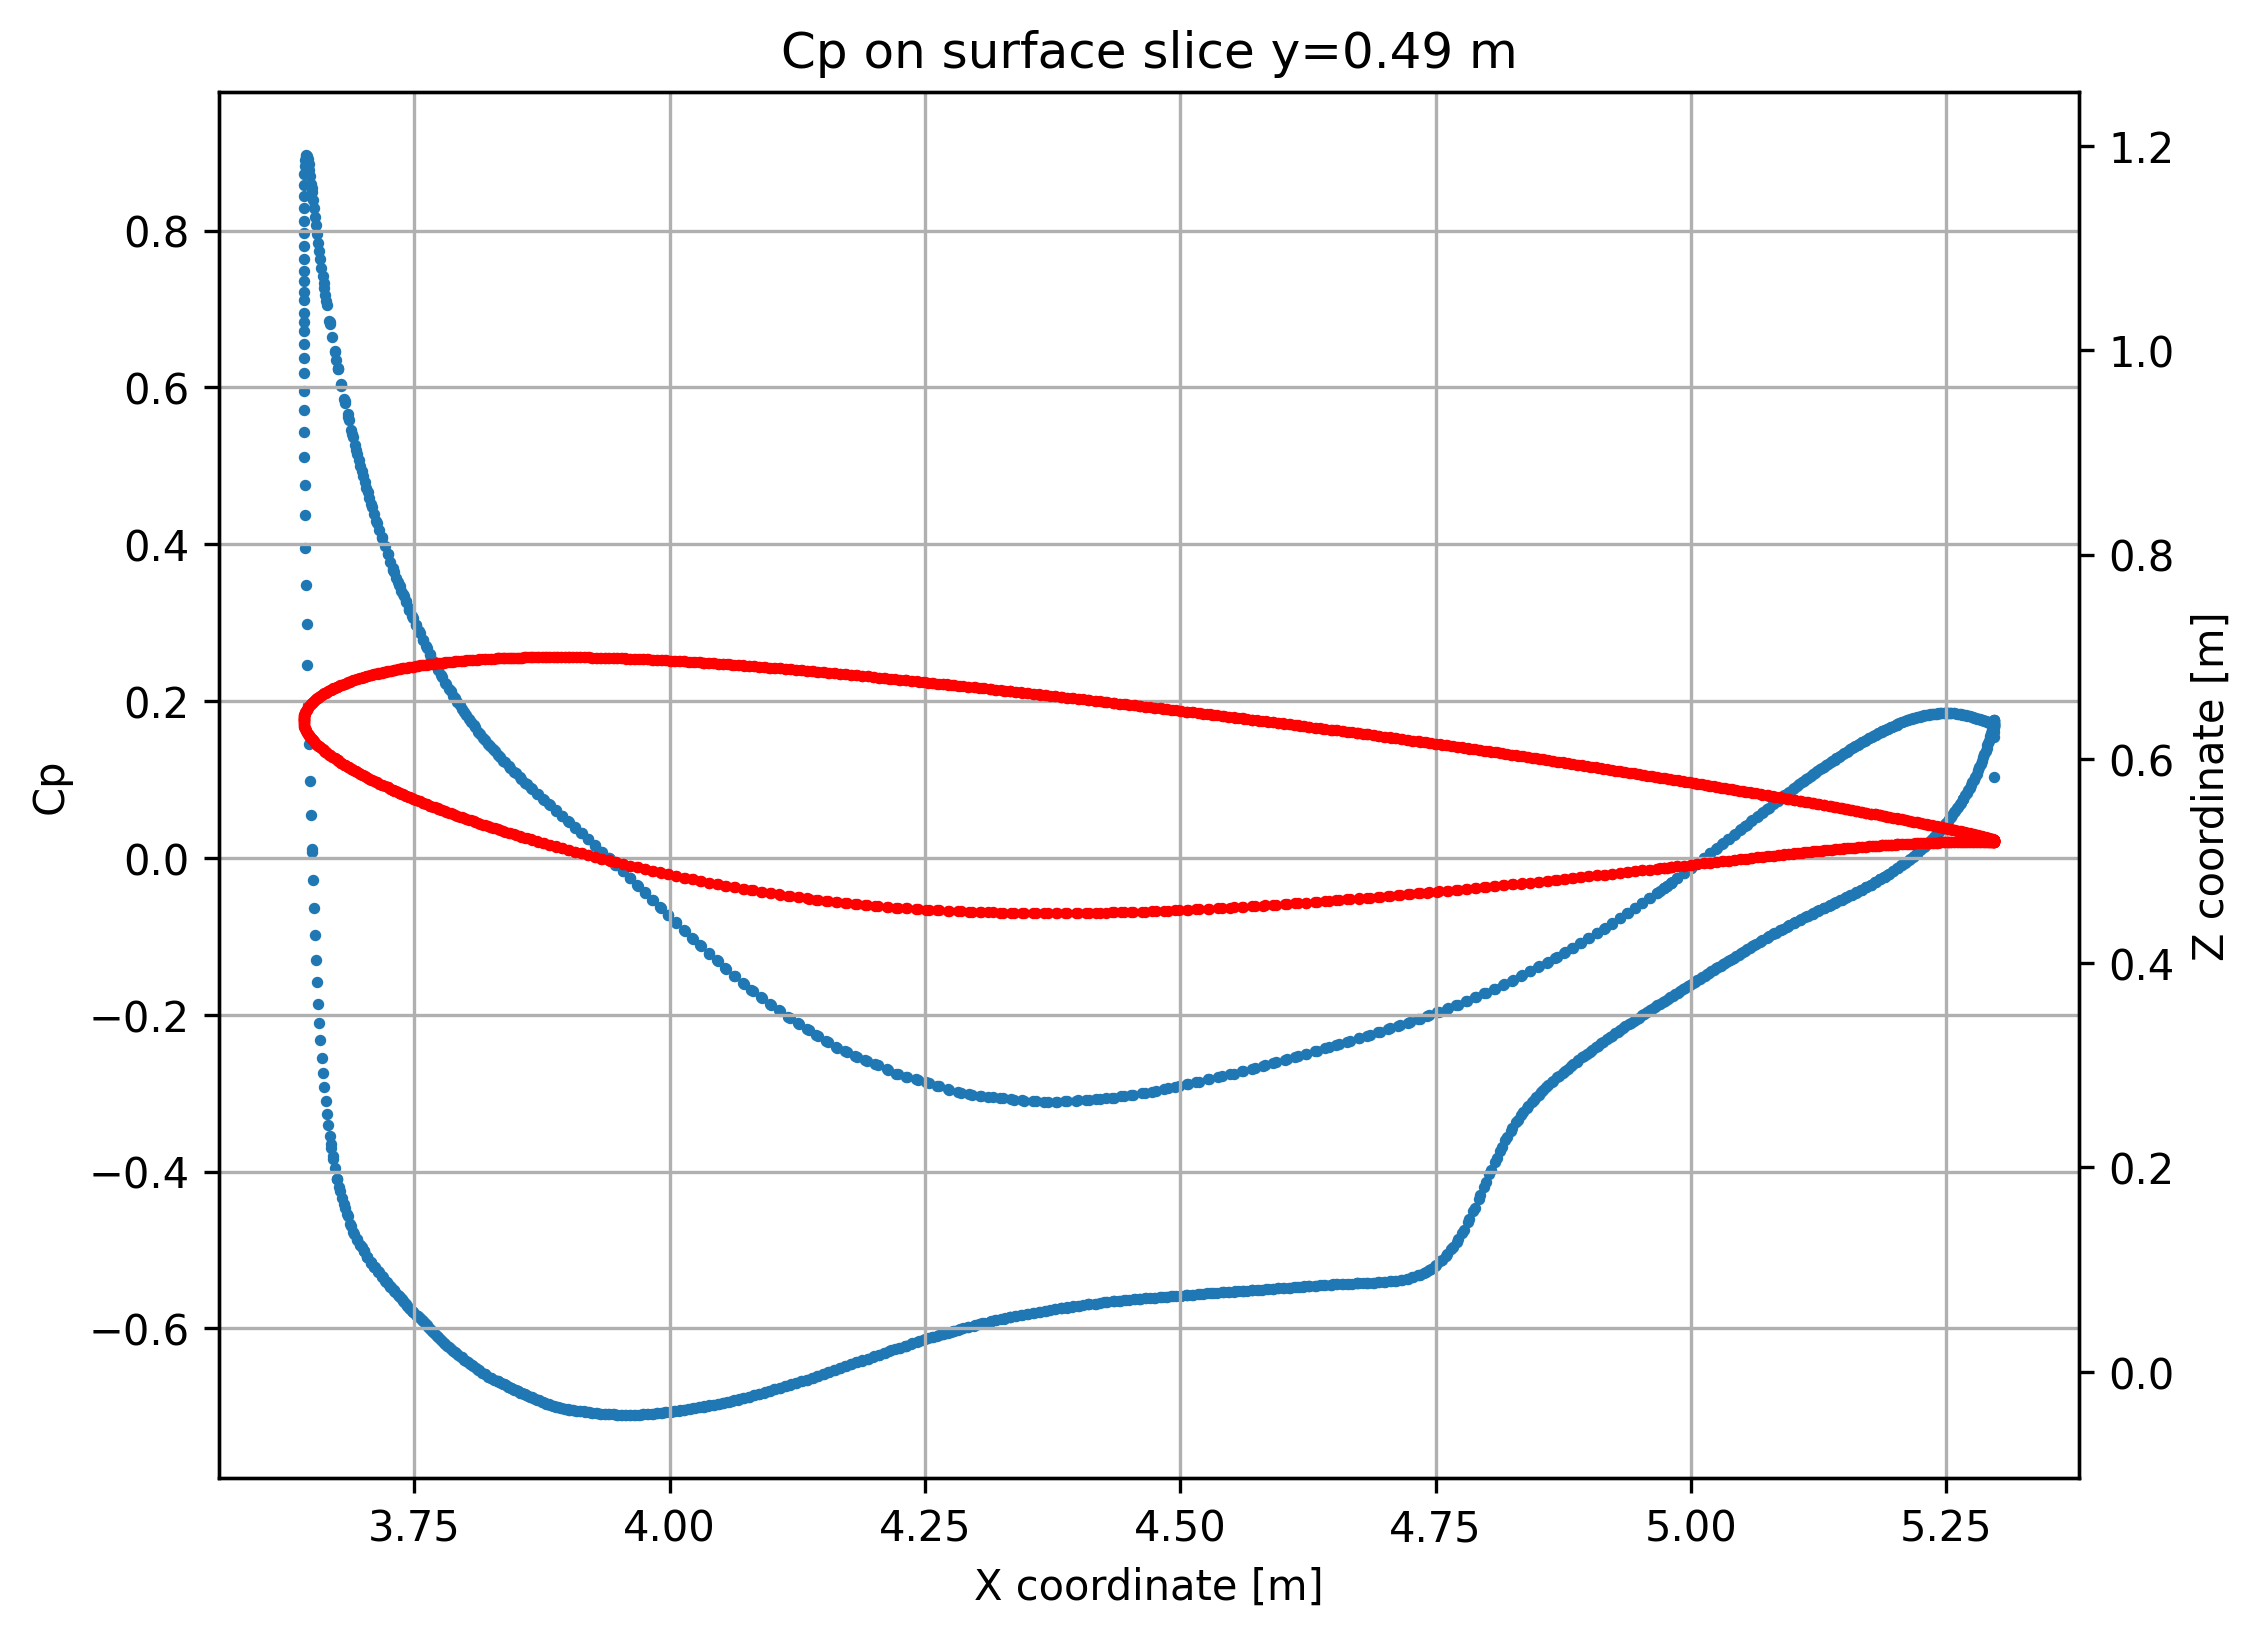

In [21]:
fig, ax = plt.subplots(figsize=(8,6), dpi=300)
ax.scatter(coords[:, 0], cps, s=3)
ax.set_xlabel("X coordinate [m]")
ax.set_ylabel("Cp")
ax.grid(True)
ax_sec = ax.twinx()
ax_sec.scatter(coords[:, 0], coords[:, 2], c="r", s=3)
ax_sec.set_aspect('equal')
ax_sec.set_ylabel("Z coordinate [m]")
ax.set_title(f"Cp on surface slice y={slice:.2f} m")
fig.show()

#### Plotting in loop
Loop that creates the plots and saves them into images folders.

In [22]:
for i, row in projects.iterrows():
    for case_id in fl.Project.from_cloud(project_id=row["project_id"]).get_case_ids():
        case_path = os.path.join(results_path, fl.Case(id=case_id).name)
        images_path = os.path.join(case_path, "images")
        os.makedirs(images_path, exist_ok=True)
        for slice in Y_SLICES:
            file_location = os.path.join(case_path, "surfaces")
            os.chdir(file_location)
            filename = f"surface_slice_slice y={slice:.2f}.pvtu"
            vtu_reader.SetFileName(filename)
            vtu_reader.Update()
            cps = numpy_support.vtk_to_numpy(vtu_reader.GetOutput().GetPointData().GetArray("Cp"))
            coords = numpy_support.vtk_to_numpy(vtu_reader.GetOutput().GetPoints().GetData())
            os.chdir(base_path)
            fig, ax = plt.subplots(figsize=(8,6), dpi=300)
            ax.scatter(coords[:, 0], cps, s=3)
            ax.set_xlabel("X coordinate [m]")
            ax.set_ylabel("Cp")
            ax.grid(True)
            ax_sec = ax.twinx()
            ax_sec.scatter(coords[:, 0], coords[:, 2], c="r", s=3)
            ax_sec.set_aspect('equal')
            ax_sec.set_ylabel("Z coordinate [m]")
            ax.set_title(f"Cp on surface slice y={slice:.2f} m")
            fig_filepath = os.path.join(images_path, f"surface_slice y={slice:.2f}.png")
            fig.savefig(fig_filepath, format="png")
            plt.clf()
            plt.close(fig)

Next, we extract images showing different solution fields as well as streamlines using the macro provided by the DPW7. The pyTecPlot library is used.

The function below is used to load the solution data into TecPlot.

In [23]:
def loadData(datafiles):
    dataset = tp.data.load_tecplot_szl(datafiles, read_data_option=tp.constant.ReadDataOption.Replace)
    frame = tp.active_frame()
    frame.plot_type = tp.constant.PlotType.Cartesian3D
    frame.activate()
    return dataset


Reading loads to include in headers.

In [24]:
loads_df = pd.read_csv(os.path.join(results_path, 'loads.csv'))
loads_df

,case_name,alpha,turbulence_model,CL_total,CD_total,CDPressure_total,CDSkinFriction_total,CL2PA_total,CMy_total,CL_wing,CD_wing,CDPressure_wing,CDSkinFriction_wing,CMy_wing,CL_fus,CD_fus,CDPressure_fus,CDSkinFriction_fus,CMy_fus
0,DPW7_JAXA_medium_LoQ_AoA2.50_SA,2.258009,SA,0.500000,0.022453,0.013115,0.009338,0.013612,-0.108635,0.436259,0.013515,0.009301,0.004214,-0.143436,0.063741,0.008938,0.003814,0.005124,0.034801
1,DPW7_JAXA_medium_LoQ_AoA2.50_SST,2.335478,SST,0.500000,0.022653,0.013397,0.009257,0.013811,-0.101876,0.435523,0.013700,0.009488,0.004212,-0.138081,0.064477,0.008953,0.003908,0.005045,0.036205
2,DPW7_JAXA_medium_LoQ_AoA2.75_SA,2.750000,SA,0.573302,0.026896,0.017653,0.009243,0.015271,-0.119772,0.500210,0.017030,0.012908,0.004123,-0.163835,0.073092,0.009865,0.004745,0.005120,0.044063
3,DPW7_JAXA_medium_LoQ_AoA2.75_SST,2.750000,SST,0.560985,0.026405,0.017221,0.009184,0.015274,-0.110935,0.488698,0.016670,0.012525,0.004145,-0.154953,0.072287,0.009735,0.004696,0.005039,0.044018
4,DPW7_JAXA_medium_LoQ_AoA3.00_SA,3.000000,SA,0.605917,0.029819,0.020641,0.009177,0.016834,-0.122869,0.528264,0.019428,0.015368,0.004060,-0.171510,0.077653,0.010391,0.005274,0.005117,0.048641
5,DPW7_JAXA_medium_LoQ_AoA3.00_SST,3.000000,SST,0.593051,0.029253,0.020125,0.009128,0.016814,-0.113798,0.516261,0.019000,0.014906,0.004093,-0.162423,0.076790,0.010254,0.005219,0.005035,0.048625
6,DPW7_JAXA_medium_LoQ_AoA3.25_SA,3.250000,SA,0.627955,0.033043,0.023936,0.009106,0.019096,-0.118407,0.546259,0.022107,0.018114,0.003993,-0.171518,0.081696,0.010936,0.005823,0.005113,0.053111
7,DPW7_JAXA_medium_LoQ_AoA3.25_SST,3.250000,SST,0.614736,0.032374,0.023311,0.009063,0.019008,-0.109674,0.533984,0.021583,0.017550,0.004032,-0.162804,0.080752,0.010791,0.005761,0.005030,0.053130
8,DPW7_JAXA_medium_LoQ_AoA3.50_SA,3.500000,SA,0.643325,0.036727,0.027688,0.009039,0.022089,-0.108744,0.557844,0.025218,0.021288,0.003930,-0.166256,0.085481,0.011508,0.006400,0.005108,0.057512
9,DPW7_JAXA_medium_LoQ_AoA3.50_SST,3.500000,SST,0.631086,0.035907,0.026912,0.008995,0.021821,-0.101836,0.546606,0.024551,0.020581,0.003970,-0.159411,0.084480,0.011356,0.006331,0.005025,0.057575


Then images are generated and saved. The image generation for all cases can take a long time (~ 1.5 hours).

In [25]:
projects = pd.read_csv("project_list.csv")
for idx, row in loads_df.iterrows():
    case_name = row["case_name"]
    surfacesList = [os.path.join(results_path, case_name, 'surfaces', "surface_"+str(x)+".szplt") for x in range(1,20) ]
    dataset = loadData(surfacesList)
    ALPHA = (row['alpha'])
    CL = (row['CL_total'])
    CD = (row['CD_total'])
    CM = (row['CMy_total'])
    solution_label= 'DPW7_JAXA_medium_LoQ_AoA_{:.2f}_turb_mod_{}'.format(ALPHA, row["turbulence_model"])

    filename = 'tp_macro.mcr'

    images_path = os.path.join(results_path, case_name, "images")
    os.makedirs(images_path, exist_ok=True)

    macro_path =  os.path.join(images_path, filename)

    # update variables in new macro and write new macro file
    with open(macro_path, "w") as f:
        f.write('#!MC 1410\n')
        f.write('\n')
        f.write('$!VarSet |SolutionLabel|=\''+solution_label+'\'\n')
        f.write('$!VarSet |OutputDirectoryPath|="'+images_path+'\\"\n')
        f.write('$!VarSet |ALPHA|=\''+"{:.2f}".format(ALPHA)+'\'\n')
        f.write('$!VarSet |CL|=\''+"{:.3f}".format(CL)+'\'\n')
        f.write('$!VarSet |CD|=\''+"{:.3f}".format(CD)+'\'\n')
        f.write('$!VarSet |CMy|=\''+"{:.3f}".format(CM)+'\'\n')
        f.write('\n')
        dir = os.path.join(os.getcwd(),"DPW-VII.Images_v7_mod.mcr")
        with open(dir, "r") as g:
            lines = g.readlines()
            for element in lines:
                f.write(element)
        f.write('\n')

    tp.macro.execute_file(macro_path)

## Processing generated files

After downloading and cleaning up the data it can be processed. Below the files will be loaded nad example plots will be drawn using the build-in pandas Dataframe plotting interface.

### Load data

In [26]:
# importing the file
loads_df = pd.read_csv(os.path.join(results_path, 'loads.csv'))
loads_df

,case_name,alpha,turbulence_model,CL_total,CD_total,CDPressure_total,CDSkinFriction_total,CL2PA_total,CMy_total,CL_wing,CD_wing,CDPressure_wing,CDSkinFriction_wing,CMy_wing,CL_fus,CD_fus,CDPressure_fus,CDSkinFriction_fus,CMy_fus
0,DPW7_JAXA_medium_LoQ_AoA2.50_SA,2.258009,SA,0.500000,0.022453,0.013115,0.009338,0.013612,-0.108635,0.436259,0.013515,0.009301,0.004214,-0.143436,0.063741,0.008938,0.003814,0.005124,0.034801
1,DPW7_JAXA_medium_LoQ_AoA2.50_SST,2.335478,SST,0.500000,0.022653,0.013397,0.009257,0.013811,-0.101876,0.435523,0.013700,0.009488,0.004212,-0.138081,0.064477,0.008953,0.003908,0.005045,0.036205
2,DPW7_JAXA_medium_LoQ_AoA2.75_SA,2.750000,SA,0.573302,0.026896,0.017653,0.009243,0.015271,-0.119772,0.500210,0.017030,0.012908,0.004123,-0.163835,0.073092,0.009865,0.004745,0.005120,0.044063
3,DPW7_JAXA_medium_LoQ_AoA2.75_SST,2.750000,SST,0.560985,0.026405,0.017221,0.009184,0.015274,-0.110935,0.488698,0.016670,0.012525,0.004145,-0.154953,0.072287,0.009735,0.004696,0.005039,0.044018
4,DPW7_JAXA_medium_LoQ_AoA3.00_SA,3.000000,SA,0.605917,0.029819,0.020641,0.009177,0.016834,-0.122869,0.528264,0.019428,0.015368,0.004060,-0.171510,0.077653,0.010391,0.005274,0.005117,0.048641
5,DPW7_JAXA_medium_LoQ_AoA3.00_SST,3.000000,SST,0.593051,0.029253,0.020125,0.009128,0.016814,-0.113798,0.516261,0.019000,0.014906,0.004093,-0.162423,0.076790,0.010254,0.005219,0.005035,0.048625
6,DPW7_JAXA_medium_LoQ_AoA3.25_SA,3.250000,SA,0.627955,0.033043,0.023936,0.009106,0.019096,-0.118407,0.546259,0.022107,0.018114,0.003993,-0.171518,0.081696,0.010936,0.005823,0.005113,0.053111
7,DPW7_JAXA_medium_LoQ_AoA3.25_SST,3.250000,SST,0.614736,0.032374,0.023311,0.009063,0.019008,-0.109674,0.533984,0.021583,0.017550,0.004032,-0.162804,0.080752,0.010791,0.005761,0.005030,0.053130
8,DPW7_JAXA_medium_LoQ_AoA3.50_SA,3.500000,SA,0.643325,0.036727,0.027688,0.009039,0.022089,-0.108744,0.557844,0.025218,0.021288,0.003930,-0.166256,0.085481,0.011508,0.006400,0.005108,0.057512
9,DPW7_JAXA_medium_LoQ_AoA3.50_SST,3.500000,SST,0.631086,0.035907,0.026912,0.008995,0.021821,-0.101836,0.546606,0.024551,0.020581,0.003970,-0.159411,0.084480,0.011356,0.006331,0.005025,0.057575


#### CL vs AoA

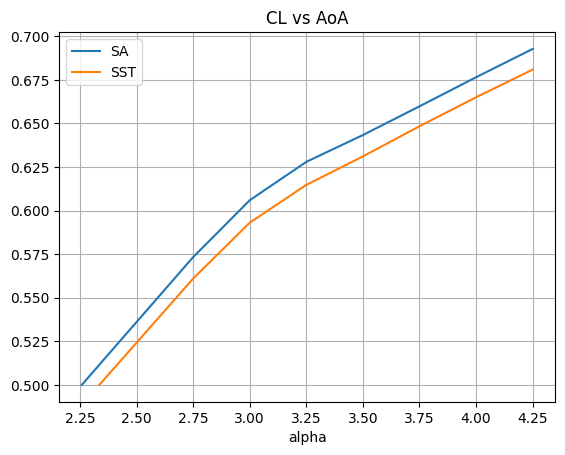

In [27]:
ax = None
for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CL_total", ax=ax, grid=True, label=group_name, title="CL vs AoA")

#### CL/CD vs Aoa

In [28]:
loads_df["CL/CD_total"] = loads_df["CL_total"] / loads_df["CD_total"]
loads_df[["CL_total", "CD_total", "CL/CD_total"]]

,CL_total,CD_total,CL/CD_total
0,0.500000,0.022453,22.268258
1,0.500000,0.022653,22.071927
2,0.573302,0.026896,21.315787
3,0.560985,0.026405,21.245720
4,0.605917,0.029819,20.320023
5,0.593051,0.029253,20.273003
6,0.627955,0.033043,19.004203
7,0.614736,0.032374,18.988794
8,0.643325,0.036727,17.516626
9,0.631086,0.035907,17.575684


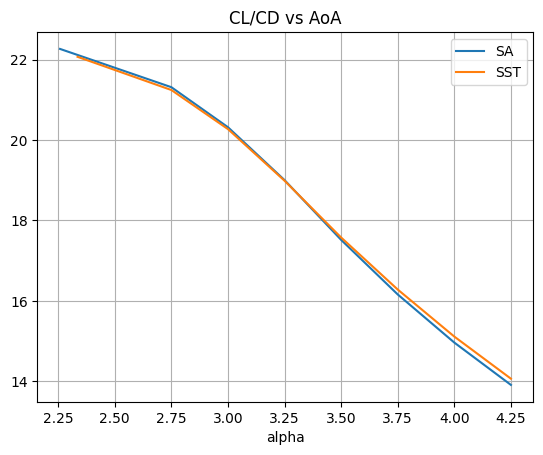

In [29]:
ax = None
for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CL/CD_total", ax=ax, grid=True, label=group_name, title="CL/CD vs AoA")

#### Drag decomposition

#### By type

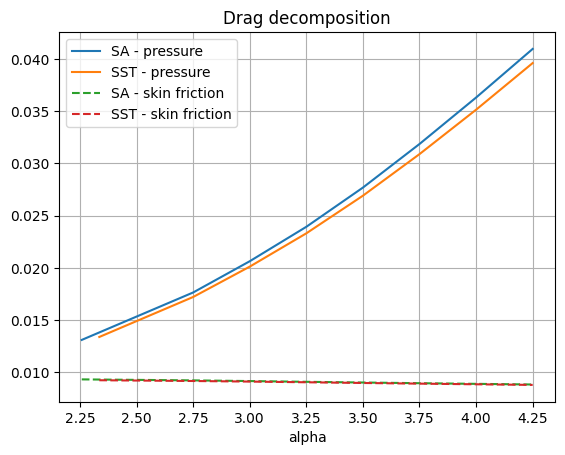

In [30]:
ax = None
for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CDPressure_total", ax=ax, grid=True, label=f"{group_name} - pressure", title="Drag decomposition")

for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CDSkinFriction_total", ax=ax, grid=True, label=f"{group_name} - skin friction", title="Drag decomposition", style="--")

#### By part

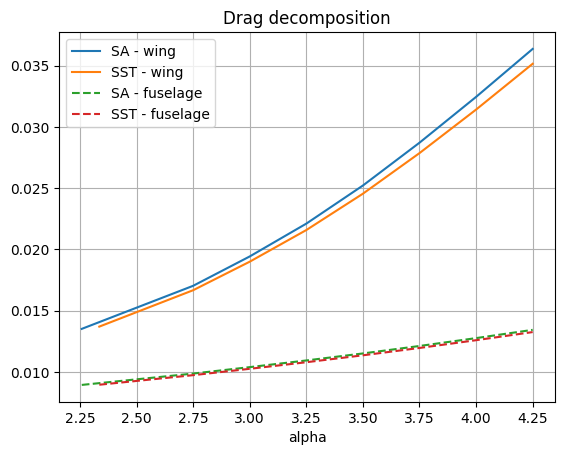

In [31]:
ax = None
for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CD_wing", ax=ax, grid=True, label=f"{group_name} - wing", title="Drag decomposition")

for group_name, group_data in loads_df.groupby("turbulence_model"):
    ax = group_data.plot(x="alpha", y="CD_fus", ax=ax, grid=True, label=f"{group_name} - fuselage", title="Drag decomposition", style="--")

### Simulation history

#### On an example case - SA, 2.5

In [32]:
alpha_base = 2.5
tb_model = "SA"
case_name = f"DPW7_JAXA_medium_LoQ_AoA{alpha_base:.2f}_{tb_model}"

history = pd.read_csv(os.path.join(results_path, case_name, "iterative_history.csv"))
history

,pseudo_step,alphaAngle,CL,CD,CMy,0_cont,1_momx,2_momy,3_momz,4_energ,5_nuHat
0,0,2.500000,0.090038,1.251197,0.201888,2.812747e-03,1.007261e-02,4.770403e-14,4.397797e-04,8.047972e-03,1.945773e-02
1,10,2.500000,0.254437,1.006006,0.265718,1.751079e-03,1.277830e-03,6.808128e-04,1.062766e-03,5.138124e-03,1.843599e-03
2,20,2.500000,0.240755,0.810002,0.235571,1.693033e-03,1.235297e-03,8.075149e-04,1.190353e-03,4.914130e-03,1.139797e-03
3,30,2.500000,0.244433,0.712796,0.226364,1.648514e-03,1.193744e-03,7.924807e-04,1.165750e-03,4.793525e-03,8.670085e-04
4,40,2.500000,0.245973,0.648395,0.219745,1.634149e-03,1.146978e-03,7.923878e-04,1.161709e-03,4.749277e-03,6.966269e-04
...,...,...,...,...,...,...,...,...,...,...,...
396,3960,2.258009,0.500000,0.022453,-0.108635,9.362475e-09,2.048816e-08,2.617556e-08,2.672189e-08,3.081626e-08,3.449803e-08
397,3970,2.258009,0.500000,0.022453,-0.108635,9.361848e-09,2.048735e-08,2.617546e-08,2.672337e-08,3.081410e-08,3.449955e-08
398,3980,2.258009,0.500000,0.022453,-0.108635,9.361923e-09,2.048799e-08,2.617594e-08,2.672178e-08,3.081494e-08,3.449642e-08
399,3990,2.258009,0.500000,0.022453,-0.108635,9.361313e-09,2.048775e-08,2.617566e-08,2.672333e-08,3.081285e-08,3.449798e-08


#### Convergence

<Axes: title={'center': 'Residual history'}, xlabel='pseudo_step'>

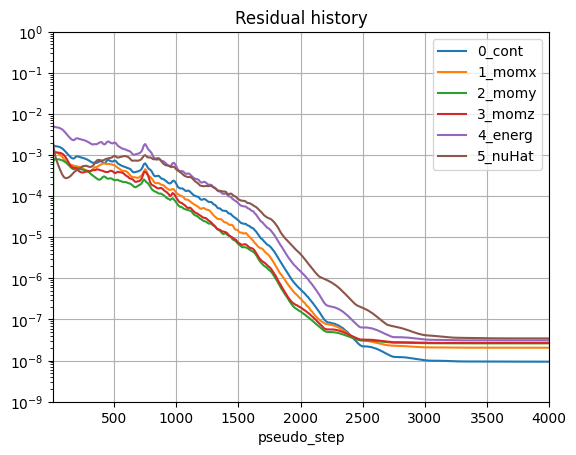

In [33]:
residuals_sa = ['0_cont', '1_momx', '2_momy', '3_momz', '4_energ', '5_nuHat']
history.plot(x="pseudo_step", y=residuals_sa, title="Residual history", grid=True, logy=True, ylim=[10e-10, 1], xlim=[10, 4000])

<Axes: title={'center': 'Drag history'}, xlabel='pseudo_step'>

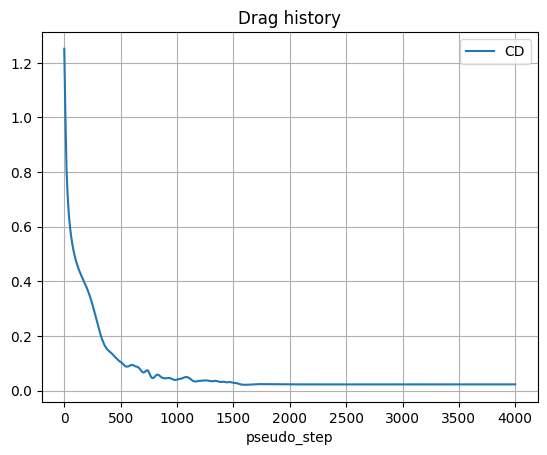

In [34]:
history.plot(x="pseudo_step", y="CD", title="Drag history", grid=True)

#### Alpha controller

The plot below shows how the Alpha controller UDD changed the variables to obtain a CL of 0.5.

<Axes: >

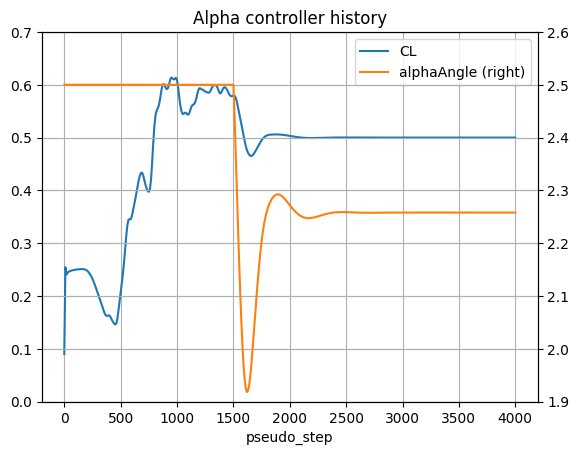

In [35]:
ax=None
ax = history.plot(x="pseudo_step", y="CL", ax=ax, title="Alpha controller history", yticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], ylim=[0, 0.7], grid=True)
history.plot(x="pseudo_step", y="alphaAngle", ax=ax, secondary_y=True, title="Alpha controller history", yticks=[1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6], ylim=[1.9, 2.6], grid=True)